In [ ]:
import networkx as nx
import pickle

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# Model names
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"  # Example Bilord model

# Paths

SAPBERT_INDEX = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"

# Load models
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

# Load FAISS indexes
sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

# Load metadata
sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# Utility functions
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

def normalize_scores(scores):
    arr = np.array(scores)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

def search_model(query, index, tokenizer, model, metadata, top_k=100):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results
# Load ICD hierarchy graph

def build_networkx_graph(root_node):
    graph = nx.Graph()
    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)
    add_nodes_edges(root_node)
    return graph

def compute_graph_cohesion(graph, candidate_codes):
    # Compute pairwise proximity among candidates
    proximity_scores = {code: 0 for code in candidate_codes}
    for i, code1 in enumerate(candidate_codes):
        for j, code2 in enumerate(candidate_codes):
            if i != j and code1 in graph and code2 in graph:
                try:
                    dist = nx.shortest_path_length(graph, source=code1, target=code2)
                    proximity_scores[code1] += 1 / (dist + 1)
                except nx.NetworkXNoPath:
                    continue
    # Normalize by number of neighbors
    for code in proximity_scores:
        proximity_scores[code] /= (len(candidate_codes) - 1)
    return proximity_scores

def late_fusion_with_graph_cohesion(query, alpha=0.5, beta=0.5, gamma=0.3, top_k=60):
    # Late fusion
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    sap_norm = normalize_scores([r["score"] for r in sap_results])
    bilord_norm = normalize_scores([r["score"] for r in bilord_results])

    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    candidate_codes = list(combined.keys())

    # Graph cohesion boost
    with open("icd_code_hierarchy.pkl", "rb") as f:
        node_dict = pickle.load(f)

    root_node = node_dict['root']
    graph = build_networkx_graph(root_node)
    cohesion_scores = compute_graph_cohesion(graph, candidate_codes)
    for code in combined:
        combined[code] += gamma * cohesion_scores.get(code, 0)

    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    return ranked

# Example usage
query = "Type 2 diabetes mellitus with neuropathy"
final_results = late_fusion_with_graph_cohesion(query)
print(final_results)


In [ ]:

import os
import pickle
import networkx as nx
import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# ===========================
# CONFIGURATION
# ===========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"

SAPBERT_INDEX = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"
ICD_GRAPH_PICKLE = "icd_code_hierarchy.pkl"

ALPHA, BETA, GAMMA = 0.5, 0.5, 0.3  # Fusion weights
TOP_K = 60

# ===========================
# MODEL & INDEX LOADING
# ===========================
def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE).eval()
    return tokenizer, model

sap_tokenizer, sap_model = load_model_and_tokenizer(SAPBERT_MODEL)
bilord_tokenizer, bilord_model = load_model_and_tokenizer(BILORD_MODEL)

def load_faiss_index(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"FAISS index not found: {path}")
    index = faiss.read_index(path)
    if not index.is_trained:
        raise ValueError(f"FAISS index at {path} is not trained.")
    return index

sap_index = load_faiss_index(SAPBERT_INDEX)
bilord_index = load_faiss_index(BILORD_INDEX)

def load_metadata(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Metadata file not found: {path}")
    df = pd.read_excel(path)
    return {i: {"code": row["Code"], "description": row["Description"]} for i, row in df.iterrows()}

sap_metadata = load_metadata(SAPBERT_META)
bilord_metadata = load_metadata(BILORD_META)

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

# ===========================
# SEARCH & NORMALIZATION
# ===========================
def softmax_normalize(scores):
    arr = np.array(scores)
    exp_arr = np.exp(arr - np.max(arr))
    return exp_arr / (exp_arr.sum() + 1e-8)

def search_model(query, index, tokenizer, model, metadata, top_k=10):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        if idx == -1:  # Handle empty results
            continue
        meta = metadata.get(idx, {"code": "UNKNOWN", "description": "N/A"})
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# ===========================
# GRAPH FUNCTIONS
# ===========================
def build_networkx_graph(root_node):
    graph = nx.Graph()
    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)
    add_nodes_edges(root_node)
    return graph

def compute_graph_cohesion(graph, candidate_codes):
    proximity_scores = {code: 0 for code in candidate_codes}
    # Precompute shortest paths for efficiency
    shortest_paths = dict(nx.all_pairs_shortest_path_length(graph))
    for code1 in candidate_codes:
        for code2 in candidate_codes:
            if code1 != code2 and code1 in shortest_paths and code2 in shortest_paths[code1]:
                dist = shortest_paths[code1][code2]
                proximity_scores[code1] += 1 / (dist + 1)
    for code in proximity_scores:
        proximity_scores[code] /= (len(candidate_codes) - 1)
    return proximity_scores

# ===========================
# LATE FUSION
# ===========================
def late_fusion_with_graph_cohesion(query, alpha=ALPHA, beta=BETA, gamma=GAMMA, top_k=TOP_K):
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    sap_norm = softmax_normalize([r["score"] for r in sap_results])
    bilord_norm = softmax_normalize([r["score"] for r in bilord_results])

    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    candidate_codes = list(combined.keys())

    # Load ICD hierarchy graph
    if not os.path.exists(ICD_GRAPH_PICKLE):
        raise FileNotFoundError(f"ICD hierarchy pickle not found: {ICD_GRAPH_PICKLE}")
    with open(ICD_GRAPH_PICKLE, "rb") as f:
        node_dict = pickle.load(f)

    root_node = node_dict.get('root')
    if root_node is None:
        raise ValueError("Root node missing in ICD hierarchy pickle.")

    graph = build_networkx_graph(root_node)
    cohesion_scores = compute_graph_cohesion(graph, candidate_codes)

    for code in combined:
        combined[code] += gamma * cohesion_scores.get(code, 0)

    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    return ranked

# ===========================
# EXAMPLE USAGE
# ===========================
if __name__ == "__main__":
    query = "Type 2 diabetes mellitus with neuropathy"
    final_results = late_fusion_with_graph_cohesion(query)
    print("Top ICD Codes:")
    for code, score in final_results[:10]:
        print(f"{code}: {score:.4f}")


In [9]:
# class for icd code hierarchial tree
class ICDcodeNode:
    def __init__(self, icd_code, description, children, parent):
        self.icd_code = icd_code
        self.description = description
        self.children  =  children
        self.parent = parent

    def get_children(self):
        return self.children
    
    def add_child(self, child):
        if child not in self.children:
            self.children.append(child)

    def get_parent(self):
        return self.parent
    
    def set_parent(self,parent):
        self.parent = parent

    def __repr__(self):
        return f'{self.icd_code} - {self.description} -  Children: {[x.icd_code for x in self.children]}'

In [ ]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# Model names
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"

# Paths
SAPBERT_INDEX = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"
ICD_GRAPH_PICKLE = r"C:\Users\UNegi\Documents\Project\makethon\icd_code_hierarchy.pkl"

# Load models
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

# Load FAISS indexes
sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

# Load metadata
sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# Utility functions
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

def softmax_normalize(scores):
    arr = np.array(scores)
    exp_arr = np.exp(arr - np.max(arr))  # stability trick
    return exp_arr / (exp_arr.sum() + 1e-8)

def search_model(query, index, tokenizer, model, metadata, top_k=100):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# Build ICD Graph
class ICDcodeNode:
    def __init__(self, icd_code, description, children=None, parent=None):
        self.icd_code = icd_code
        self.description = description
        self.children = children if children else []
        self.parent = parent

    def get_children(self):
        return self.children

def build_networkx_graph(root_node):
    graph = nx.Graph()
    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)
    add_nodes_edges(root_node)
    return graph

def compute_graph_cohesion(graph, candidate_codes):
    proximity_scores = {code: 0 for code in candidate_codes}
    shortest_paths = dict(nx.all_pairs_shortest_path_length(graph))
    for code1 in candidate_codes:
        for code2 in candidate_codes:
            if code1 != code2 and code1 in shortest_paths and code2 in shortest_paths[code1]:
                dist = shortest_paths[code1][code2]
                proximity_scores[code1] += 1 / (dist + 1)
    for code in proximity_scores:
        proximity_scores[code] /= (len(candidate_codes) - 1)
    return proximity_scores

def late_fusion_with_graph(query, alpha=0.5, beta=0.5, gamma=0.3, top_k=10):
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    sap_norm = softmax_normalize([r["score"] for r in sap_results])
    bilord_norm = softmax_normalize([r["score"] for r in bilord_results])

    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    candidate_codes = list(combined.keys())

    # Load ICD hierarchy graph
    with open(ICD_GRAPH_PICKLE, "rb") as f:
        node_dict = pickle.load(f)
    root_node = node_dict['root']
    graph = build_networkx_graph(root_node)

    cohesion_scores = compute_graph_cohesion(graph, candidate_codes)
    for code in combined:
        combined[code] += gamma * cohesion_scores.get(code, 0)

    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)

    formatted_results = []
    for code, score in ranked:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = bilord_meta_df.loc[bilord_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (combined)": round(score, 4)
        })

    return formatted_results

# Example usage
query = "Type 2 diabetes mellitus with neuropathy"
final_results = late_fusion_with_graph(query)
for res in final_results[:10]:
    print(res)


In [ ]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ===========================
# MODEL CONFIG
# ===========================
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"

SAPBERT_INDEX = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"
ICD_GRAPH_PICKLE = r"C:\Users\UNegi\Documents\Project\makethon\icd_code_hierarchy.pkl"

# ===========================
# LOAD MODELS & INDEXES
# ===========================
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

def softmax_normalize(scores):
    arr = np.array(scores)
    exp_arr = np.exp(arr - np.max(arr))  # stability trick
    return exp_arr / (exp_arr.sum() + 1e-8)

# ===========================
# SEARCH FUNCTIONS
# ===========================
def search_model(query, index, tokenizer, model, metadata, top_k=100):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# ===========================
# BUILD ICD GRAPH
# ===========================
class ICDcodeNode:
    def __init__(self, icd_code, description, children=None, parent=None):
        self.icd_code = icd_code
        self.description = description
        self.children = children if children else []
        self.parent = parent

    def get_children(self):
        return self.children

def build_networkx_graph(root_node):
    graph = nx.Graph()
    def add_nodes_edges(node):
        graph.add_node(node.icd_code, description=node.description)
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)
    add_nodes_edges(root_node)
    return graph

with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['root']
graph = build_networkx_graph(root_node)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

# ===========================
# LATE FUSION + PROXIMITY BOOST
# ===========================
def late_fusion_with_graph_proximity(query, alpha=0.5, beta=0.5, gamma=0.3, top_k=100):
    # Step 1: Retrieve candidates
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    # Step 2: Normalize scores
    sap_norm = softmax_normalize([r["score"] for r in sap_results])
    bilord_norm = softmax_normalize([r["score"] for r in bilord_results])
    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    # Step 3: Late fusion
    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    # Step 4: Get top candidate and anchor
    ranked_initial = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    top_code = ranked_initial[0][0]
    query_anchor = top_code[:3]  # first three letters (chapter/block)

    # Step 5: Graph-based proximity boost
    for code in combined:
        if query_anchor in graph and code in graph:
            try:
                dist = nx.shortest_path_length(graph, source=query_anchor, target=code)
                boost = 1 / (dist + 1)
            except nx.NetworkXNoPath:
                boost = 0
            combined[code] += gamma * boost

    # Step 6: Final ranking
    ranked_final = sorted(combined.items(), key=lambda x: x[1], reverse=True)

    # Format results
    formatted_results = []
    for code, score in ranked_final:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = bilord_meta_df.loc[bilord_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (combined)": round(score, 4)
        })

    return formatted_results

# ===========================
# TEST PIPELINE
# ===========================
query = "COPD"
final_results = late_fusion_with_graph_proximity(query)
print("Top 10 ICD codes after late fusion + proximity boost:")
for res in final_results[:25]:
    print(res)


In [10]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ===========================
# MODEL CONFIG
# ===========================
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"

SAPBERT_INDEX = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
BILORD_META = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"
ICD_GRAPH_PICKLE = r"C:\Users\UNegi\Documents\Project\makethon\icd_code_hierarchy.pkl"

# ===========================
# LOAD MODELS & INDEXES
# ===========================
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

def softmax_normalize(scores):
    arr = np.array(scores)
    exp_arr = np.exp(arr - np.max(arr))  # stability trick
    return exp_arr / (exp_arr.sum() + 1e-8)

# ===========================
# SEARCH FUNCTIONS
# ===========================
def search_model(query, index, tokenizer, model, metadata, top_k=100):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# ===========================
# LOAD ICD GRAPH
# ===========================
with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['root']
graph = nx.Graph()

def build_networkx_graph(node):
    graph.add_node(node.icd_code, description=node.description)
    for child in node.get_children():
        graph.add_edge(node.icd_code, child.icd_code)
        build_networkx_graph(child)

build_networkx_graph(root_node)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

# ===========================
# LATE FUSION + GRAPH BOOSTING
# ===========================
def late_fusion_with_graph_proximity(query, alpha=0.5, beta=0.5, gamma=0.3, top_k=100):
    # Step 1: Retrieve candidates
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    # Step 2: Normalize scores
    sap_norm = softmax_normalize([r["score"] for r in sap_results])
    bilord_norm = softmax_normalize([r["score"] for r in bilord_results])
    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    # Step 3: Late fusion
    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    # Step 4: Anchor ICD code
    ranked_initial = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    anchor_code = ranked_initial[0][0]

    # Step 5: Graph-based boosting
    boosted_nodes = {}
    if anchor_code in graph:
        boosted_nodes[anchor_code] = gamma * 1.0
        # Parent
        parents = [n for n in graph.neighbors(anchor_code) if n != anchor_code]
        for p in parents:
            boosted_nodes[p] = gamma * 0.8
            # Parent's siblings
            for sib in graph.neighbors(p):
                if sib != anchor_code:
                    boosted_nodes[sib] = gamma * 0.6
        # Children
        for child in graph.neighbors(anchor_code):
            boosted_nodes[child] = gamma * 0.7

    # Apply boost
    for code, boost in boosted_nodes.items():
        if code in combined:
            combined[code] += boost

    # Step 6: Normalize to 100
    scores = list(combined.values())
    min_score, max_score = min(scores), max(scores)
    normalized_combined = {code: 100 * (score - min_score) / (max_score - min_score) for code, score in combined.items()}

    # Step 7: Final ranking
    ranked_final = sorted(normalized_combined.items(), key=lambda x: x[1], reverse=True)

    # Format results
    formatted_results = []
    for code, score in ranked_final:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = bilord_meta_df.loc[bilord_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (0-100)": round(score, 2)
        })

    return formatted_results, anchor_code, boosted_nodes

# ===========================
# VISUALIZATION FUNCTION
# ===========================
def visualize_boosted_graph(anchor_code, boosted_nodes):
    pos = nx.spring_layout(graph)
    node_colors = []
    node_sizes = []
    for node in graph.nodes():
        if node == anchor_code:
            node_colors.append("red")
            node_sizes.append(800)
        elif node in boosted_nodes:
            node_colors.append("orange")
            node_sizes.append(600)
        else:
            node_colors.append("lightgray")
            node_sizes.append(300)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, font_size=8)
    plt.title(f"Graph Boost Visualization (Anchor: {anchor_code})")
    plt.show()

# ===========================
# TEST PIPELINE
# ===========================
query = "COPD"
final_results, anchor_code, boosted_nodes = late_fusion_with_graph_proximity(query)
print("Top 10 ICD codes after late fusion + proximity boost:")
for res in final_results[:30]:
    print(res)

#visualize_boosted_graph(anchor_code, boosted_nodes)


Graph loaded: 97802 nodes, 97831 edges
Top 10 ICD codes after late fusion + proximity boost:
{'ICD_Code': 'J449', 'Description': 'Chronic obstructive pulmonary disease, unspecified', 'Score (0-100)': np.float64(100.0)}
{'ICD_Code': 'J4489', 'Description': 'Other specified chronic obstructive pulmonary disease', 'Score (0-100)': np.float64(87.51)}
{'ICD_Code': 'J849', 'Description': 'Interstitial pulmonary disease, unspecified', 'Score (0-100)': np.float64(81.03)}
{'ICD_Code': 'J984', 'Description': 'Other disorders of lung', 'Score (0-100)': np.float64(80.41)}
{'ICD_Code': 'J441', 'Description': 'Chronic obstructive pulmonary disease with (acute) exacerbation', 'Score (0-100)': np.float64(78.61)}
{'ICD_Code': 'J42', 'Description': 'Unspecified chronic bronchitis', 'Score (0-100)': np.float64(78.54)}
{'ICD_Code': 'J64', 'Description': 'Unspecified pneumoconiosis', 'Score (0-100)': np.float64(77.16)}
{'ICD_Code': 'J8410', 'Description': 'Pulmonary fibrosis, unspecified', 'Score (0-100)':

In [11]:

# Check if J44 exists in the graph
if "J44" in graph:
    # Get all neighbors of J44
    neighbors = list(graph.neighbors("J44"))
    print(f"Neighbors of J44: {neighbors}")
else:
    print("J44 not found in graph")


Neighbors of J44: ['J40-J4A', 'J440', 'J441', 'J448', 'J449']


In [18]:

import pandas as pd
import faiss
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import pickle
import networkx as nx
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

# ===========================
# CONFIG
# ===========================
SAPBERT_MODEL = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BILORD_MODEL = "FremyCompany/BioLORD-2023"

SAPBERT_INDEX = r"C:\\Users\\UNegi\\Downloads\\icd10_faiss_sapbert_from_pubmedbert.index"
SAPBERT_META = r"C:\\Users\\UNegi\\Downloads\\icd10_metadata_sapbert_from_pubmedbert.xlsx"
BILORD_INDEX = r"C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd10_faiss_biolord.index"
BILORD_META = r"C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd10_metadata_biolord.xlsx"
ICD_GRAPH_PICKLE = r"C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd_code_hierarchy.pkl"

# ===========================
# LOAD MODELS & INDEXES
# ===========================
sap_tokenizer = AutoTokenizer.from_pretrained(SAPBERT_MODEL)
sap_model = AutoModel.from_pretrained(SAPBERT_MODEL).to(DEVICE).eval()

bilord_tokenizer = AutoTokenizer.from_pretrained(BILORD_MODEL)
bilord_model = AutoModel.from_pretrained(BILORD_MODEL).to(DEVICE).eval()

sap_index = faiss.read_index(SAPBERT_INDEX)
bilord_index = faiss.read_index(BILORD_INDEX)

sap_meta_df = pd.read_excel(SAPBERT_META)
bilord_meta_df = pd.read_excel(BILORD_META)

sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in sap_meta_df.iterrows()}
bilord_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in bilord_meta_df.iterrows()}

# ===========================
# EMBEDDING FUNCTIONS
# ===========================
def mean_pooling(last_hidden_state, attention_mask):
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)

def embed_texts(texts, tokenizer, model):
    all_embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
            out = model(**enc)
            emb = mean_pooling(out.last_hidden_state, enc["attention_mask"])
            emb = emb.cpu().numpy()
            all_embs.append(emb)
    embs = np.vstack(all_embs).astype("float32")
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)  # L2 normalization
    return embs

def softmax_normalize(scores):
    arr = np.array(scores)
    exp_arr = np.exp(arr - np.max(arr))  # stability trick
    return exp_arr / (exp_arr.sum() + 1e-8)

# ===========================
# SEARCH FUNCTION
# ===========================
def search_model(query, index, tokenizer, model, metadata, top_k=100):
    q_emb = embed_texts([query], tokenizer, model)
    D, I = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        meta = metadata[idx]
        results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
    return results

# ===========================
# LOAD ICD GRAPH
# ===========================
with open(ICD_GRAPH_PICKLE, "rb") as f:
    node_dict = pickle.load(f)
root_node = node_dict['root']
graph = nx.Graph()

def build_networkx_graph(node):
    graph.add_node(node.icd_code, description=node.description)
    for child in node.get_children():
        graph.add_edge(node.icd_code, child.icd_code)
        build_networkx_graph(child)

build_networkx_graph(root_node)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

# ===========================
# BOOSTING LOGIC
# ===========================
def late_fusion_with_graph_proximity(query, alpha=0.5, beta=0.5, gamma=0.3, top_k=100):
    sap_results = search_model(query, sap_index, sap_tokenizer, sap_model, sap_metadata, top_k)
    bilord_results = search_model(query, bilord_index, bilord_tokenizer, bilord_model, bilord_metadata, top_k)

    sap_norm = softmax_normalize([r["score"] for r in sap_results])
    bilord_norm = softmax_normalize([r["score"] for r in bilord_results])
    for i, r in enumerate(sap_results): r["norm_score"] = sap_norm[i]
    for i, r in enumerate(bilord_results): r["norm_score"] = bilord_norm[i]

    combined = {}
    for r in sap_results:
        combined[r["code"]] = alpha * r["norm_score"]
    for r in bilord_results:
        combined[r["code"]] = combined.get(r["code"], 0) + beta * r["norm_score"]

    ranked_initial = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    anchor_code = ranked_initial[0][0]

    boosted_nodes = {}
    if anchor_code in graph:
        boosted_nodes[anchor_code] = gamma * 1.0
        for parent in graph.neighbors(anchor_code):
            boosted_nodes[parent] = gamma * 0.8
            for sib in graph.neighbors(parent):
                if sib != anchor_code:
                    boosted_nodes[sib] = gamma * 0.6
            for gp in graph.neighbors(parent):
                if gp != anchor_code and gp != parent:
                    boosted_nodes[gp] = gamma * 0.7
                    for block_child in graph.neighbors(gp):
                        if block_child != parent:
                            boosted_nodes[block_child] = gamma * 0.6

    for code, boost in boosted_nodes.items():
        if code in combined:
            combined[code] += boost

    scores = list(combined.values())
    min_score, max_score = min(scores), max(scores)
    normalized_combined = {code: 100 * (score - min_score) / (max_score - min_score) for code, score in combined.items()}

    ranked_final = sorted(normalized_combined.items(), key=lambda x: x[1], reverse=True)

    formatted_results = []
    for code, score in ranked_final:
        description = sap_meta_df.loc[sap_meta_df["Code"] == code, "Description"].values
        if len(description) == 0:
            description = bilord_meta_df.loc[bilord_meta_df["Code"] == code, "Description"].values
        description = description[0] if len(description) > 0 else "Description not found"
        formatted_results.append({
            "ICD_Code": code.strip(),
            "Description": description,
            "Score (0-100)": round(score, 2)
        })

    return formatted_results, anchor_code, boosted_nodes

# ===========================
# VISUALIZATION
# ===========================
def visualize_boosted_graph(anchor_code, boosted_nodes):
    pos = nx.spring_layout(graph, seed=42)
    node_colors = []
    node_sizes = []
    for node in graph.nodes():
        if node == anchor_code:
            node_colors.append("red")
            node_sizes.append(900)
        elif node in boosted_nodes:
            node_colors.append("orange" if boosted_nodes[node] >= 0.7 else "yellow")
            node_sizes.append(700)
        else:
            node_colors.append("lightgray")
            node_sizes.append(400)
    plt.figure(figsize=(12, 8))
    nx.draw(graph, pos, with_labels=True, node_color=node_colors, node_size=node_sizes, font_size=8)
    plt.title(f"ICD Graph Boost Visualization (Anchor: {anchor_code})")
    plt.show()

# ===========================
# TEST PIPELINE
# ===========================
query = "COPD"
final_results, anchor_code, boosted_nodes = late_fusion_with_graph_proximity(query)
print("Top 10 ICD codes after late fusion + hierarchy boost:")
for res in final_results[:10]:
    print(res)



RuntimeError: Error in __cdecl faiss::FileIOReader::FileIOReader(const char *) at D:\a\faiss-wheels\faiss-wheels\third-party\faiss\faiss\impl\io.cpp:70: Error: 'f' failed: could not open C:\\Users\\UNegi\\Documents\\Project\\makethon\\icd10_faiss_biolord.index for reading: No such file or directory

In [13]:
for res in final_results[:30]:
    print(res)

{'ICD_Code': 'J449', 'Description': 'Chronic obstructive pulmonary disease, unspecified', 'Score (0-100)': np.float64(100.0)}
{'ICD_Code': 'J4489', 'Description': 'Other specified chronic obstructive pulmonary disease', 'Score (0-100)': np.float64(87.51)}
{'ICD_Code': 'J849', 'Description': 'Interstitial pulmonary disease, unspecified', 'Score (0-100)': np.float64(81.03)}
{'ICD_Code': 'J984', 'Description': 'Other disorders of lung', 'Score (0-100)': np.float64(80.41)}
{'ICD_Code': 'J441', 'Description': 'Chronic obstructive pulmonary disease with (acute) exacerbation', 'Score (0-100)': np.float64(78.61)}
{'ICD_Code': 'J42', 'Description': 'Unspecified chronic bronchitis', 'Score (0-100)': np.float64(78.54)}
{'ICD_Code': 'J64', 'Description': 'Unspecified pneumoconiosis', 'Score (0-100)': np.float64(77.16)}
{'ICD_Code': 'J8410', 'Description': 'Pulmonary fibrosis, unspecified', 'Score (0-100)': np.float64(76.79)}
{'ICD_Code': 'J989', 'Description': 'Respiratory disorder, unspecified', 

In [15]:

# -*- coding: utf-8 -*-
"""
Hierarchical Graph Traversal (MedGraphRAG-style) with SapBERT + BioLORD fusion.
Layers:
  - L0 (Vocabulary): ICD codes (your current graph) + optional UMLS concepts
  - L1 (Literature): Textbook sections / papers (optional)
  - L2 (Private): Clinical notes / user docs (optional)

Retrieval:
  - Top-down Precise Retrieval: query -> L0 seeds -> expand to L1/L2 via graph
  - Bottom-up Response Refinement: leaf docs -> back to concepts/codes for coverage
Scoring:
  - semantic (FAISS) + graph_proximity + coverage + role-aware boosts
Output:
  - Ranked ICD codes, evidence nodes (docs), path rationale, score 0–100

References:
  - MedGraphRAG triple graph + U-Retrieval (arXiv & repo)  [see citations in response]
  - GraphRAG hierarchical traversal principle               [see citations in response]
"""

import os
import math
import json
import pickle
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import torch
import faiss
import networkx as nx

from transformers import AutoTokenizer, AutoModel

# --------------------------
# CONFIG
# --------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

@dataclass
class Weights:
    # Fusion weights for embedding-based similarity
    alpha: float = 0.5  # SapBERT
    beta: float = 0.5   # BioLORD

    # Graph role-aware boosts (per edge role and layer)
    boost_anchor: float = 1.00
    boost_parent: float = 0.80
    boost_sibling: float = 0.60
    boost_child: float = 0.70
    boost_block: float = 0.70      # parent’s parent (block)
    boost_block_child: float = 0.60

    # Global gamma scaling for graph proximity
    gamma: float = 0.30

    # U-Retrieval mixing
    lambda_topdown: float = 0.6
    lambda_bottomup: float = 0.4

    # Normalization epsilon
    eps: float = 1e-8


@dataclass
class Paths:
    # HF models
    sapbert_model: str = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
    biolord_model: str = "FremyCompany/BioLORD-2023"
    # Indexes & metadata
    sapbert_index: str = r"C:\Users\UNegi\Downloads\icd10_faiss_sapbert_from_pubmedbert.index"
    sapbert_meta: str  = r"C:\Users\UNegi\Downloads\icd10_metadata_sapbert_from_pubmedbert.xlsx"
    biolord_index: str = r"C:\Users\UNegi\Documents\Project\makethon\icd10_faiss_biolord.index"
    biolord_meta: str  = r"C:\Users\UNegi\Documents\Project\makethon\icd10_metadata_biolord.xlsx"
    # ICD graph (pickle of ICDcodeNode tree)
    icd_graph_pickle: str = r"C:\Users\UNegi\Documents\Project\makethon\icd_code_hierarchy.pkl"
    # Optional concept/doc indexes (if you add UMLS or papers later)
    umls_index: Optional[str] = None
    umls_meta: Optional[str]  = None
    docs_index: Optional[str] = None
    docs_meta: Optional[str]  = None


# --------------------------
# EMBEDDING FUSION
# --------------------------
class EmbeddingFusion:
    """Embed queries with SapBERT + BioLORD and fuse scores."""

    def __init__(self, paths: Paths, weights: Weights):
        self.weights = weights
        # Load HF models
        self.sap_tokenizer = AutoTokenizer.from_pretrained(paths.sapbert_model)
        self.sap_model = AutoModel.from_pretrained(paths.sapbert_model).to(DEVICE).eval()
        self.bil_tokenizer = AutoTokenizer.from_pretrained(paths.biolord_model)
        self.bil_model = AutoModel.from_pretrained(paths.biolord_model).to(DEVICE).eval()
        # FAISS indexes
        self.sap_index = faiss.read_index(paths.sapbert_index)
        self.bil_index = faiss.read_index(paths.biolord_index)
        # Metadata
        self.sap_meta_df = pd.read_excel(paths.sapbert_meta)
        self.bil_meta_df = pd.read_excel(paths.biolord_meta)
        self.sap_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in self.sap_meta_df.iterrows()}
        self.bil_metadata = {i: {"code": row["Code"], "description": row["Description"]} for i, row in self.bil_meta_df.iterrows()}

    @staticmethod
    def mean_pooling(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        return (last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

    def embed(self, texts: List[str], tokenizer, model) -> np.ndarray:
        all_embs = []
        with torch.no_grad():
            for i in range(0, len(texts), BATCH_SIZE):
                batch = texts[i:i+BATCH_SIZE]
                enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
                out = model(**enc)
                emb = self.mean_pooling(out.last_hidden_state, enc["attention_mask"]).cpu().numpy()
                all_embs.append(emb)
        embs = np.vstack(all_embs).astype("float32")
        embs /= (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-9)  # L2 norm
        return embs

    @staticmethod
    def _softmax_normalize(scores: List[float]) -> np.ndarray:
        arr = np.array(scores, dtype=np.float32)
        exp_arr = np.exp(arr - np.max(arr))
        return exp_arr / (exp_arr.sum() + 1e-8)

    def _search(self, query: str, index, tokenizer, model, metadata, top_k=100) -> List[Dict[str, Any]]:
        q_emb = self.embed([query], tokenizer, model)
        D, I = index.search(q_emb, top_k)
        results = []
        for score, idx in zip(D[0], I[0]):
            meta = metadata[idx]
            results.append({"code": meta["code"], "description": meta["description"], "score": float(score), "id": idx})
        return results

    def search_fused_codes(self, query: str, top_k=100) -> List[Dict[str, Any]]:
        sap_results = self._search(query, self.sap_index, self.sap_tokenizer, self.sap_model, self.sap_metadata, top_k)
        bil_results = self._search(query, self.bil_index, self.bil_tokenizer, self.bil_model, self.bil_metadata, top_k)
        sap_norm = self._softmax_normalize([r["score"] for r in sap_results])
        bil_norm = self._softmax_normalize([r["score"] for r in bil_results])
        combined: Dict[str, float] = {}
        for i, r in enumerate(sap_results):
            combined[r["code"]] = self.weights.alpha * float(sap_norm[i])
        for i, r in enumerate(bil_results):
            combined[r["code"]] = combined.get(r["code"], 0.0) + self.weights.beta * float(bil_norm[i])

        # Produce list with descriptions
        out = []
        for code, fused in sorted(combined.items(), key=lambda x: x[1], reverse=True):
            # prefer Sap meta, fallback BioLORD
            desc = self.sap_meta_df.loc[self.sap_meta_df["Code"] == code, "Description"].values
            if len(desc) == 0:
                desc = self.bil_meta_df.loc[self.bil_meta_df["Code"] == code, "Description"].values
            desc = desc[0] if len(desc) > 0 else "Description not found"
            out.append({"code": code, "description": desc, "fused": fused})
        return out


# --------------------------
# MULTI-LAYER GRAPH
# --------------------------
class MultiLayerGraph:
    """
    Holds per-layer graphs and cross-layer edges.

    L0: vocab_graph (ICD tree + optional UMLS concepts)
    L1: literature_graph (sections/papers)
    L2: private_graph (clinical notes)
    cross_edges: list of (src, dst, role, weight, layer_src, layer_dst)
    """
    def __init__(self):
        self.vocab_graph = nx.DiGraph()    # ICD/UMLS
        self.lit_graph   = nx.DiGraph()    # textbooks/papers
        self.private_graph = nx.DiGraph()  # notes
        self.cross_edges: List[Tuple[str, str, str, float, str, str]] = []

    def add_vocab_node(self, node_id: str, **attrs):
        self.vocab_graph.add_node(node_id, **attrs)

    def add_vocab_edge(self, src: str, dst: str, role: str = "parent_child", weight: float = 1.0):
        self.vocab_graph.add_edge(src, dst, role=role, weight=weight)

    def add_cross_link(self, src: str, dst: str, role: str, weight: float, layer_src: str, layer_dst: str):
        self.cross_edges.append((src, dst, role, weight, layer_src, layer_dst))

    def neighbors_vocab(self, node_id: str) -> List[str]:
        # undirected feeling across parent/child; consider both in/out
        nbrs = set(self.vocab_graph.predecessors(node_id)) | set(self.vocab_graph.successors(node_id))
        return list(nbrs)

    def get_edge_role_weight_vocab(self, src: str, dst: str) -> Tuple[str, float]:
        data = self.vocab_graph.get_edge_data(src, dst)
        if data is None:
            data = self.vocab_graph.get_edge_data(dst, src)
        if data is None:
            return ("unlinked", 0.0)
        return (data.get("role", "parent_child"), float(data.get("weight", 1.0)))


# --------------------------
# ICD GRAPH LOADING
# --------------------------
class ICDGraphLoader:
    """Builds vocab_graph from your ICDcodeNode pickle."""
    def __init__(self, paths: Paths):
        self.paths = paths

    def load(self) -> nx.DiGraph:
        with open(self.paths.icd_graph_pickle, "rb") as f:
            node_dict = pickle.load(f)
        root = node_dict["root"]

        G = nx.DiGraph()
        def add_recursive(node):
            G.add_node(node.icd_code, description=node.description, type="ICD")
            for child in node.get_children():
                # parent -> child
                G.add_edge(node.icd_code, child.icd_code, role="parent_child", weight=1.0)
                add_recursive(child)
        add_recursive(root)
        return G


# --------------------------
# TRAVERSAL ENGINE (U-Retrieval style)
# --------------------------
class TraversalEngine:
    """
    Orchestrates:
      - Top-down precise retrieval from L0 seeds
      - Graph-aware expansion with role boosts
      - Bottom-up refinement from leaf docs
      - Score aggregation and normalization
    """
    def __init__(self, fusion: EmbeddingFusion, mgraph: MultiLayerGraph, weights: Weights):
        self.fusion = fusion
        self.mgraph = mgraph
        self.w = weights

    # ---- role-aware boosting on vocab (ICD) ----
    def _boost_vocab_scores(self, anchor_code: str, scores: Dict[str, float]) -> Dict[str, float]:
        # Anchor
        scores[anchor_code] = scores.get(anchor_code, 0.0) + self.w.gamma * self.w.boost_anchor

        # Parent(s) of anchor (predecessors)
        parents = list(self.mgraph.vocab_graph.predecessors(anchor_code))
        for p in parents:
            scores[p] = scores.get(p, 0.0) + self.w.gamma * self.w.boost_parent
            # Siblings of anchor (other children of parent)
            for sib in self.mgraph.vocab_graph.successors(p):
                if sib != anchor_code:
                    scores[sib] = scores.get(sib, 0.0) + self.w.gamma * self.w.boost_sibling
            # Parent's parent (block)
            gparents = list(self.mgraph.vocab_graph.predecessors(p))
            for gp in gparents:
                scores[gp] = scores.get(gp, 0.0) + self.w.gamma * self.w.boost_block
                # All children of block (siblings of parent; includes emphysema block mate)
                for block_child in self.mgraph.vocab_graph.successors(gp):
                    if block_child != p:
                        scores[block_child] = scores.get(block_child, 0.0) + self.w.gamma * self.w.boost_block_child

        # Children of anchor
        for ch in self.mgraph.vocab_graph.successors(anchor_code):
            scores[ch] = scores.get(ch, 0.0) + self.w.gamma * self.w.boost_child

        return scores

    # ---- Top-down: query -> fused code seeds -> graph expansion ----
    def top_down_precise(self, query: str, top_k_codes: int = 50) -> Dict[str, float]:
        fused = self.fusion.search_fused_codes(query, top_k=top_k_codes)
        # start with fused semantic scores
        scores = {r["code"]: r["fused"] for r in fused}

        # choose anchor = highest fused
        if not fused:
            return scores
        anchor_code = fused[0]["code"]

        # apply role-aware boosts on vocab layer (ICD)
        scores = self._boost_vocab_scores(anchor_code, scores)

        # OPTIONAL: expand to literature/private layers via cross_edges (if provided)
        # This is where MedGraphRAG links vocab -> papers/sections -> private notes
        # For simplicity, we keep vocab scoring here. You can add cross-layer scoring later.

        return scores

    # ---- Bottom-up: refine from leaf docs back to vocab (coverage & consistency) ----
    def bottom_up_refine(self, docs_support: Dict[str, List[str]]) -> Dict[str, float]:
        """
        docs_support: mapping code -> list of doc_ids that mention/justify the code
        Returns coverage_score per code (more distinct docs -> higher coverage).
        """
        coverage: Dict[str, float] = {}
        for code, doc_list in docs_support.items():
            unique_docs = len(set(doc_list))
            coverage[code] = math.log(1 + unique_docs)
        return coverage

    # ---- Aggregate scores ----
    def aggregate_scores(self, semantic_graph_scores: Dict[str, float], coverage_scores: Optional[Dict[str, float]] = None) -> Dict[str, float]:
        coverage_scores = coverage_scores or {}
        final: Dict[str, float] = {}
        for code, s in semantic_graph_scores.items():
            c = coverage_scores.get(code, 0.0)
            final[code] = self.w.lambda_topdown * s + self.w.lambda_bottomup * c
        return final

    @staticmethod
    def normalize_0_100(scores: Dict[str, float]) -> Dict[str, float]:
        if not scores:
            return {}
        vals = np.array(list(scores.values()), dtype=np.float32)
        mn, mx = float(vals.min()), float(vals.max())
        if abs(mx - mn) < 1e-12:
            return {k: 100.0 for k in scores}
        return {k: 100.0 * (v - mn) / (mx - mn) for k, v in scores.items()}

    def retrieve(self, query: str, k: int = 25) -> List[Dict[str, Any]]:
        # 1) Top-down
        td_scores = self.top_down_precise(query, top_k_codes=max(100, k * 4))

        # 2) Bottom-up (optional until you wire docs)
        # Provide docs_support if you have linked documents; otherwise keep empty.
        bu_scores = self.bottom_up_refine(docs_support={})  # TODO: fill when docs are available

        # 3) Aggregate
        final_scores = self.aggregate_scores(td_scores, bu_scores)

        # 4) Normalize & rank
        ranked = sorted(self.normalize_0_100(final_scores).items(), key=lambda x: x[1], reverse=True)

        # 5) Format with description
        results: List[Dict[str, Any]] = []
        for code, score in ranked[:k]:
            desc = self.fusion.sap_meta_df.loc[self.fusion.sap_meta_df["Code"] == code, "Description"].values
            if len(desc) == 0:
                desc = self.fusion.bil_meta_df.loc[self.fusion.bil_meta_df["Code"] == code, "Description"].values
            desc = desc[0] if len(desc) > 0 else "Description not found"
            results.append({"ICD_Code": code, "Description": desc, "Score (0-100)": round(score, 2)})
        return results


# --------------------------
# WIRING IT ALL TOGETHER
# --------------------------
def build_system(paths: Paths, weights: Weights) -> Tuple[TraversalEngine, MultiLayerGraph]:
    # 1) ICD vocab graph
    icd_loader = ICDGraphLoader(paths)
    vocab_graph = icd_loader.load()

    # 2) Multi-layer container
    mgraph = MultiLayerGraph()
    mgraph.vocab_graph = vocab_graph  # use your ICD graph as L0

    # 3) Embedding fusion (SapBERT + BioLORD)
    fusion = EmbeddingFusion(paths, weights)

    # 4) Traversal engine
    engine = TraversalEngine(fusion, mgraph, weights)
    return engine, mgraph


# --------------------------
# EXAMPLE USAGE
# --------------------------
if __name__ == "__main__":
    paths = Paths()
    weights = Weights()

    engine, mgraph = build_system(paths, weights)

    query = "COPD"
    results = engine.retrieve(query, k=25)
    print("\nTop ICD codes (MedGraphRAG-style traversal with fusion + role boosts):")
    for r in results:
        print(r)


NetworkXError: The node J449     is not in the digraph.

Built graph


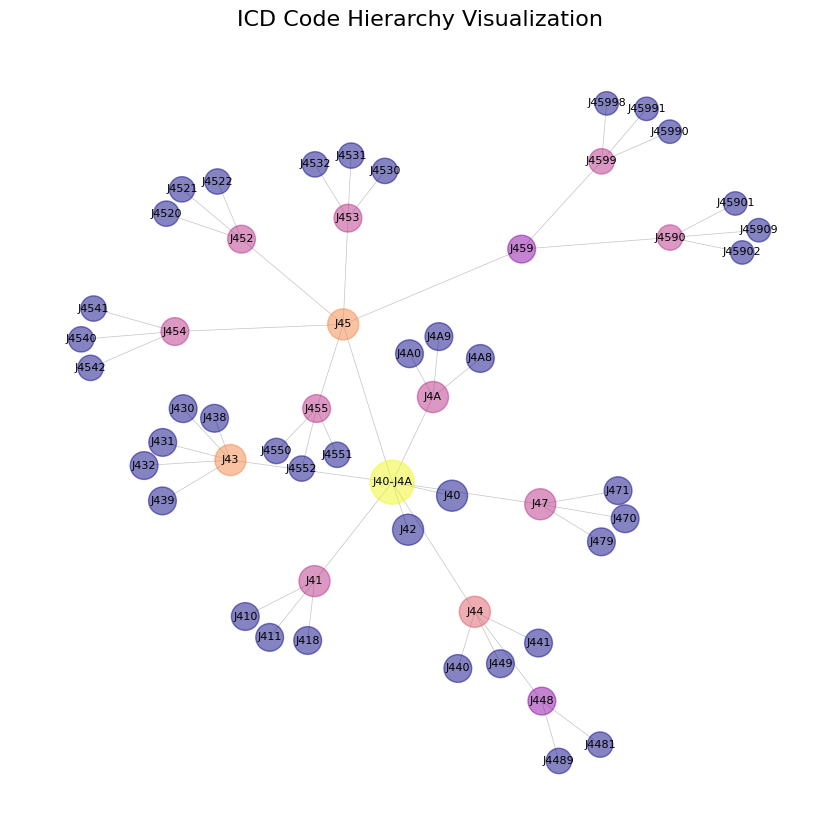

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

def build_networkx_graph(root_node):
    """Convert ICDcodeNode tree to NetworkX graph"""
    graph = nx.Graph()

    def add_nodes_edges(node):
        # Add node with its ICD code and description as attributes
        graph.add_node(node.icd_code, description=node.description)

        # Add edges for each child
        for child in node.get_children():
            graph.add_edge(node.icd_code, child.icd_code)
            add_nodes_edges(child)

    add_nodes_edges(root_node)
    return graph

def visualize_large_graph(graph):
    """Visualize NetworkX graph with matplotlib"""
    pos = nx.spring_layout(graph, k=0.1, iterations=100) #spacing between nodes

    plt.figure(figsize=(8.5, 8.5))

    # Draw edges
    nx.draw_networkx_edges(graph, pos, alpha=0.5, width=0.5, edge_color='#888')

    # Draw nodes
    node_sizes = []
    for node in graph.nodes():
        # Size inversely proportional to ICD code length (longer codes are lower in the hierarchy)
        code_length = len(node)
        if '-' in node: #(code is a section/chapter)
            code_length = 1
        node_sizes.append(1 / (code_length + 1) * 2000)  # Scale factor

    nx.draw_networkx_nodes(
        graph, pos, 
        node_size=node_sizes,
        node_color=[len(graph.edges(n)) for n in graph.nodes()],
        cmap=plt.cm.plasma, alpha=0.5
    )

    # Add labels to nodes (ICD codes)
    labels = {node: node for node in graph.nodes()}
    nx.draw_networkx_labels(graph, pos, labels, font_size=8)

    plt.title('ICD Code Hierarchy Visualization', fontsize=16)
    plt.axis('off') 
    plt.tight_layout()
    plt.show()


root_node = node_dict['J40-J4A']

# Convert to NetworkX graph and visualize
graph = build_networkx_graph(root_node)
print('Built graph')
visualize_large_graph(graph)

In [1]:
import pandas as pd

In [5]:
df = pd.read_excel('test.xlsx')

In [3]:
df1

,Unnamed: 0,code,description,confidence
0,0,E162,"Hypoglycemia, unspecified",100.00
1,1,E161,Other hypoglycemia,95.76
2,2,E16A2,Hypoglycemia level 2,93.84
3,3,E16A3,Hypoglycemia level 3,92.56
4,4,E16A1,Hypoglycemia level 1,91.16
...,...,...,...,...
319,319,T7582XA,"Effects of weightlessness, initial encounter",0.01
320,320,E2681,Bartter's syndrome,0.01
321,321,Y901,Blood alcohol level of 20-39 mg/100 ml,0.01
322,322,M21379,"Foot drop, unspecified foot",0.00


In [17]:
df_master = pd.read_excel(r"C:\Users\UNegi\Documents\Project\makethon\ICD_10_CM_Complete_Data.xlsx")

In [6]:
filt_code = df['code'].tolist()

In [7]:
filt_code

['E162',
 'E161',
 'E16A2',
 'E16A3',
 'E16A1',
 'R7301',
 'R739',
 'E11649',
 'E13649',
 'T383X6A',
 'E11641',
 'R7309',
 'P704',
 'E15',
 'T383X6D',
 'E160',
 'E860',
 'E88819',
 'E10649',
 'E08649',
 'R7302',
 'E8351',
 'T383X6S',
 'I959',
 'D72819',
 'E876',
 'E10641',
 'R636',
 'Z7984',
 'E09649',
 'R81',
 'P703',
 'O99810',
 'R7303',
 'O99814',
 'E09641',
 'E861',
 'E1165',
 'R682',
 'E891',
 'Y900',
 'D72818',
 'E8342',
 'E88818',
 'T383X5A',
 'I951',
 'O924',
 'E8720',
 'R031',
 'T383X1A',
 'T383X5D',
 'E74819',
 'F32A',
 'R7981',
 'E569',
 'O24425',
 'R001',
 'Z131',
 'T383X2A',
 'O24415',
 'R799',
 'T383X2D',
 'E039',
 'T383X4A',
 'Z72820',
 'E611',
 'E1065',
 'T505X6A',
 'D72810',
 'T503X6D',
 'Z6791',
 'T503X6A',
 'E785',
 'R571',
 'R6881',
 'R790',
 'E13641',
 'E08641',
 'O2492',
 'O24912',
 'R110',
 'E232',
 'O24913',
 'O2432',
 'E10A0',
 'O24919',
 'E118',
 'D649',
 'O24911',
 'E138',
 'E1140',
 'O2493',
 'O99815',
 'R6882',
 'I9589',
 'O24312',
 'E088',
 'E1101',
 'E134

In [16]:

df_master['Code'] = df_master['Code'].str.strip()
df_master.to_excel(r"C:\Users\UNegi\Documents\Project\makethon\ICD_10_CM_Complete_Data.xlsx")

In [14]:
filt_codes = ['E162']

df_filt = df_master[df_master['Code'].isin(filt_codes)]
print(df_filt)


Empty DataFrame
Columns: [Unnamed: 0, Code, Description, Code_Grouper, Grouper_description, Section, Section_Name, sec_start, sec_end, Chapter, Chapter_Name]
Index: []


In [8]:
df_filt = df_master[df_master['Code'].isin(filt_code)]

In [10]:
df_filt


,Unnamed: 0,Code,Description,Code_Grouper,Grouper_description,Section,Section_Name,sec_start,sec_end,Chapter,Chapter_Name


In [ ]:

df_topk = df.sort_values(by="confidence", ascending=False).head(10)

filt_code = df_topk['code'].tolist()
df_topk['code_3'] = df_topk['code'].astype(str).str.strip().str[:3]
filt_code_3 = df_topk['code_3'].tolist()
filt_code_3_unique = list(set(filt_code_3))



In [ ]:

def show_interactive():
    st.title("Interactive Mapping")
    st.markdown("Real-time AI lookup for clinical terminology.")

    # --- Session state defaults ---
    defaults = {
        "mapped": False,
        "results_df": None,
        "systems_last": None,
        "top_k_last": 5,
        "query_last": "",
        "selected_chapter": None,
        "show_tree": False,
    }
    for k, v in defaults.items():
        st.session_state.setdefault(k, v)

    with st.container():
        c1, c2 = st.columns([3, 1])
        with c1:
            # persist last query in the input
            query = st.text_input("Search Term", placeholder="e.g. Chest pain, Hypertension...", value=st.session_state.get("query_last", ""))
        with c2:
            # use a widget key to avoid clashes and persist selection
            top_k = st.selectbox("Limit Results", [1, 3, 5, 10, "All"], index=2, key="top_k_ui")

        systems = st.selectbox(
            "Filter by System",
            ["ICD-10-CM", "ICD-10-PCS", "CPT"],
            index=0,
            key="systems_ui"
        )

        if st.button("Map Term"):
            if query:
                with st.spinner("Running AI Model..."):
                    df = pd.DataFrame()
                    time.sleep(0.5)
                    if not systems:
                        st.warning("Please select a Code Type (ICD-10 CM / ICD-10 PCS / CPT).")
                    else:
                        try:
                            if systems == 'ICD-10-CM':
                                df = icd_10_cm_search_bar(query)
                                df.rename(columns={'Score (0-100)': 'confidence', 'ICD_Code': 'code','Description':'description'}, inplace=True)
                            elif systems == 'ICD-10-PCS':
                                df = search_icd10_pcs_search_bar(query)
                            else:  # CPT
                                df = cpt_search_bar(query)
                        except Exception as e:
                            st.error(f"Error while fetching results: {e}")
                            df = pd.DataFrame()

                    # --- Persist everything needed to render after reruns ---
                    st.session_state.results_df = df
                    st.session_state.systems_last = systems
                    st.session_state.top_k_last = top_k
                    st.session_state.query_last = query
                    st.session_state.mapped = True
                    # reset ontology view when remapping
                    st.session_state.show_tree = False
            else:
                st.info("Enter a term to begin mapping.")

    # --- Render from session state so the view survives reruns ---
    if st.session_state.mapped and st.session_state.results_df is not None and not st.session_state.results_df.empty:
        df = st.session_state.results_df.copy()
        systems = st.session_state.systems_last
        top_k = st.session_state.top_k_last

        # Common: sort & limit
        try:
            limit = len(df) if top_k == "All" else int(top_k)
        except Exception:
            limit = 5  # fallback

        if systems == 'ICD-10-CM':
            # Ensure numeric for sorting
            if 'confidence' in df.columns:
                df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce').fillna(0)

            df_topk = df.sort_values(by="confidence", ascending=False).head(limit)
            df_topk['code_3'] = df_topk['code'].astype(str).str.strip().str[:3]
            grouper = sorted(set(df_topk['code_3'].tolist()))

            results = df.to_dict(orient='records')
            results.sort(key=lambda x: x.get('confidence', 0), reverse=True)
            st.markdown(f"### Found {len(results[:limit])} Matches")
            for item in results[:limit]:
                confidence_pct = int(item.get('confidence', 0))
                code = item.get("code", "")
                color = "#10b981" if confidence_pct > 50 else "#f59e0b"
                st.markdown(f"""
                            <div class="result-card">
                            <div style="display:flex; justify-content:space-between; align-items:center;">
                                <div>
                                    <span style="background:#fdf2f8; color:#db2777; padding:2px 8px; border-radius:4px; font-size:0.75rem; font-weight:bold;">{systems}</span>
                                    <h3 style="margin:4px 0 0 0; color:#0f172a;">{code}</h3>
                                </div>
                                <div style="text-align:right;">
                                    <div style="font-size:1.25rem; font-weight:bold; color:{color};">{confidence_pct}%</div>
                                    <div style="font-size:0.75rem; color:#64748b;">Confidence</div>
                                </div>
                            </div>
                            <p style="margin-top:8px; color:#334155;">{item.get('description', '')}</p>
                        </div>
                        """, unsafe_allow_html=True)

            # ICD-10-CM ONTOLOGY SECTION
            selected_chapter = st.selectbox("Select Chapter", grouper, key="select_chapter")
            st.session_state.selected_chapter = selected_chapter

            # Use selected_chapter for the tree button (code variable outside loop is unreliable)
            if st.button(f"Show ICD Ontology Tree for {selected_chapter}", key=f"tree_btn_{selected_chapter}"):
                st.session_state.show_tree = True

            if st.session_state.show_tree and st.session_state.selected_chapter:
                try:
                    node = node_dict[st.session_state.selected_chapter]
                    graph = build_networkx_graph(node)
                    fig = plt.figure(figsize=(8, 8))
                    visualize_large_graph(graph)
                    buf = BytesIO()
                    plt.savefig(buf, format="png")
                    st.image(buf)
                except Exception as e:
                    st.error(f"Ontology visualization error: {e}")

        else:
            results = df.to_dict(orient='records')
            results.sort(key=lambda x: x.get('confidence', 0), reverse=True)
            st.markdown(f"### Found {len(results[:limit])} Matches")
            for item in results[:limit]:
                confidence_pct = int(item.get('confidence', 0))
                color = "#10b981" if confidence_pct > 50 else "#f59e0b"
                st.markdown(f"""
                            <div class="result-card">
                                <div style="display:flex; justify-content:space-between; align-items:center;">
                                    <div>
                                        <span style="background:#fdf2f8; color:#db2777; padding:2px 8px; border-radius:4px; font-size:0.75rem; font-weight:bold;">{systems}</span>
                                        <h3 style="margin:4px 0 0 0; color:#0f172a;">{item.get('code','')}</h3>
                                    </div>
                                    <div style="text-align:right;">
                                        <div style="font-size:1.25rem; font-weight:bold; color:{color};">{confidence_pct}%</div>
                                        <div style="font-size:0.75rem; color:#64748b;">Confidence</div>
                                    </div>
                                </div>
                                <p style="margin-top:8px; color:#334155;">{item.get('description','')}</p>
                            </div>
                            """, unsafe_allow_html=True)
    else:
        # Only show this when nothing has been mapped yet
        if not st.session_state.mapped:
            st.info("Enter a term to begin mapping.")


In [45]:
filt_code_3_unique

['E11', 'E13', 'T38', 'R73', 'E16']

In [43]:

df_top25.tolist().unique()

AttributeError: 'DataFrame' object has no attribute 'tolist'

In [ ]:

df_top25 = df.sort_values(by="confidence", ascending=False).head(10)

filt_code = df_top25['code'].tolist()
df_top25['code_3'] = df_top25['code'].astype(str).str.strip().str[:3]

df_filt = df_master[df_master['Code'].isin(filt_code)]
chapters = df_filt['Section'].unique()
section = df_filt['Chapter'].unique()
df_view =  pd.merge(df, df_filt, left_on="code",right_on="Code" ,how="inner")

In [37]:
df_top25

,Unnamed: 0,code,description,confidence
0,0,E162,"Hypoglycemia, unspecified",100.00
1,1,E161,Other hypoglycemia,95.76
2,2,E16A2,Hypoglycemia level 2,93.84
3,3,E16A3,Hypoglycemia level 3,92.56
4,4,E16A1,Hypoglycemia level 1,91.16
5,5,R7301,Impaired fasting glucose,90.80
6,6,R739,"Hyperglycemia, unspecified",89.79
7,7,E11649,Type 2 diabetes mellitus with hypoglycemia wit...,88.18
8,8,E13649,Other specified diabetes mellitus with hypogly...,87.47
9,9,T383X6A,Underdosing of insulin and oral hypoglycemic [...,87.01


In [38]:
df_top25

,Unnamed: 0,code,description,confidence
0,0,E162,"Hypoglycemia, unspecified",100.00
1,1,E161,Other hypoglycemia,95.76
2,2,E16A2,Hypoglycemia level 2,93.84
3,3,E16A3,Hypoglycemia level 3,92.56
4,4,E16A1,Hypoglycemia level 1,91.16
5,5,R7301,Impaired fasting glucose,90.80
6,6,R739,"Hyperglycemia, unspecified",89.79
7,7,E11649,Type 2 diabetes mellitus with hypoglycemia wit...,88.18
8,8,E13649,Other specified diabetes mellitus with hypogly...,87.47
9,9,T383X6A,Underdosing of insulin and oral hypoglycemic [...,87.01


In [39]:
chapters

array(['E08-E13 ', 'E15-E16 ', 'R70-R79 ', 'T07-T88 '], dtype=object)

In [40]:
section

array(['Chapter E00-E89 ', 'Chapter R00-R99 ', 'Chapter S00-T88 '],
      dtype=object)

In [ ]:
import streamlit as st
import pandas as pd
import time
import matplotlib.pyplot as plt
from io import BytesIO

def show_interactive():
st.title("Medical Code Semantic Mapping")
st.markdown("Real-time AI mapping + ICD-10 Ontology reasoning.")

```
# ------------------------
# INPUT SECTION
# ------------------------
with st.container():
    c1, c2 = st.columns([3, 1])
    with c1:
        query = st.text_input("Search Term", placeholder="e.g. Chest pain, COPD, Hypertension...")
    with c2:
        top_k = st.selectbox("Limit Results", [1, 3, 5, 10, "All"], index=2)

    systems = st.selectbox(
        "Code System",
        ["ICD-10-CM", "ICD-10-PCS", "CPT"],
        index=2
    )

    if st.button("Map Term"):
        if not query:
            st.info("Enter a search term.")
            return

        with st.spinner("Running AI Model..."):
            time.sleep(0.3)
            df = None

            try:
                if systems == "ICD-10-CM":
                    df = icd_10_cm_search_bar(query)
                    df.rename(columns={
                        "ICD_Code": "code",
                        "Description": "description",
                        "Score (0-100)": "confidence"
                    }, inplace=True)

                elif systems == "ICD-10-PCS":
                    df = search_icd10_pcs_search_bar(query)

                else:
                    df = cpt_search_bar(query)

            except Exception as e:
                st.error(f"Error: {e}")
                return

        # ------------------------
        # DISPLAY SEARCH RESULTS
        # ------------------------
        results = df.to_dict(orient="records")
        results.sort(key=lambda x: x["confidence"], reverse=True)
        limit = len(results) if top_k == "All" else int(top_k)

        st.markdown(f"### Found {limit} Matches")

        for item in results[:limit]:
            conf = int(item["confidence"])
            code = item["code"]
            desc = item["description"]

            color = "#10b981" if conf > 50 else "#f59e0b"

            with st.container():
                with st.expander(f"{code} — {desc[:60]}..."):
                    # ------------------------
                    # MAIN CARD
                    # ------------------------
                    st.markdown(f"""
                    <div style="padding:10px; border-radius:10px; background:#f8fafc;">
                        <div style="display:flex; justify-content:space-between;">
                            <div>
                                <span style="background:#fdf2f8; color:#db2777;
                                    padding:3px 8px; border-radius:6px; 
                                    font-size:0.75rem; font-weight:bold;">{systems}</span>
                                <h3 style="margin:4px 0; color:#0f172a;">{code}</h3>
                            </div>
                            <div style="text-align:right;">
                                <div style="font-size:1.3rem; font-weight:bold; color:{color};">
                                    {conf}%</div>
                                <div style="font-size:0.75rem; color:#64748b;">Confidence</div>
                            </div>
                        </div>

                        <p style="margin-top:6px; color:#334155;">{desc}</p>
                    </div>
                    """, unsafe_allow_html=True)

                    # ------------------------
                    # ICD-10-CM ONTOLOGY SECTION
                    # ------------------------
                    if systems == "ICD-10-CM" and code in node_dict:
                        node = node_dict[code]

                        st.subheader("📘 Ontology Hierarchy")

                        # Parent chain
                        chain = []
                        temp = node
                        while temp:
                            chain.append(f"{temp.icd_code} — {temp.description}")
                            temp = temp.parent
                        chain = chain[::-1]

                        st.markdown("**Hierarchy Path:**")
                        for level in chain:
                            st.markdown(f"- {level}")

                        # ------------------------
                        # RELATED CODES
                        # ------------------------
                        st.subheader("🔗 Related Codes (Ontology)")

                        parent = node.parent
                        if parent:
                            siblings = [c for c in parent.get_children() if c.icd_code != code]
                            st.markdown("**Sibling Codes:**")
                            for sib in siblings[:6]:
                                st.markdown(f"- {sib.icd_code} — {sib.description}")
                        else:
                            st.write("No siblings found.")

                        children = node.get_children()
                        if children:
                            st.markdown("**Child Codes:**")
                            for ch in children[:6]:
                                st.markdown(f"- {ch.icd_code} — {ch.description}")

                        # ------------------------
                        # EXPLANATION PANEL
                        # ------------------------
                        st.subheader("🧠 Why This Code Matched")

                        st.markdown("""
                            - Semantic similarity using medical embeddings  
                            - Synonym & abbreviation expansion  
                            - Contextual clinical term matching  
                            - Query → Code similarity score  
                        """)

                        # ------------------------
                        # SUBTREE VISUALIZATION BUTTON
                        # ------------------------
                        if st.button(f"Show ICD Ontology Tree for {code}", key=f"tree_{code}"):
                            graph = build_networkx_graph(node)
                            fig = plt.figure(figsize=(8, 8))
                            visualize_large_graph(graph)
                            buf = BytesIO()
                            plt.savefig(buf, format="png")
                            st.image(buf)
                    else:
                        st.info("Ontology visualization only available for ICD-10-CM codes.")
```
